<a href="https://colab.research.google.com/github/haten95/Actividades_IA/blob/main/Actividad_2_Ivan_Rodriguez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Alumno: Iván Rodríguez Cruz
# ai_videogames · Reto evaluable PRO
## Transfer Learning para criaturas RPG

### Objetivo
Construir un clasificador de criaturas inspirado en RPG usando **Oxford-IIIT Pet** y una arquitectura preentrenada.

### Metas orientativas
- **Accuracy ≥ 0.80** en fase 1
- **Accuracy ≥ 0.85** tras fine-tuning

> No son obligatorias si tu análisis es bueno, pero sirven como referencia.


In [15]:
!pip install tensorflow
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 160
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# 1. CAMBIO: División en 3 conjuntos (Train, Val, Test)
# Usamos el 80% de train para entrenar, el 20% restante para validar,
# y el 'test' oficial para la evaluación final.
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=['train[:80%]', 'train[80%:]', 'test'],
    with_info=True,
    as_supervised=True
)

label_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes
print("Clases:", num_classes)

# 2. CAMBIO: Función de preprocesamiento
def preprocess_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Importante: No normalizamos a mano (/255) aquí porque
    # la mayoría de modelos preentrenados de Keras traen su propia capa de escalado.
    return image, label

# Aplicamos el preprocesamiento y configuramos el pipeline de datos
# Nota: Todavía no aplicamos .batch() ni .prefetch() aquí. Lo haremos en la siguiente celda
# después de aplicar la función de `preprocess` específica del modelo.
ds_train = ds_train.map(preprocess_image, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.map(preprocess_image, num_parallel_calls=AUTOTUNE)
ds_test = ds_test.map(preprocess_image, num_parallel_calls=AUTOTUNE)

# 3. CAMBIO: Optimización de memoria y velocidad
# Aplicamos cacheo y shuffle (solo para entrenamiento) aquí.
# El batching y prefetching se aplicarán en la siguiente celda después del preprocess específico del modelo.
ds_train = ds_train.cache().shuffle(1000)
ds_val = ds_val.cache()
ds_test = ds_test.cache()

Clases: 37


#**¿Por qué hemos hecho estos cambios?**
#División en tres (Train/Val/Test):
En el código original, el 20% que se separaba era la única forma de medir el éxito. Al separar en Entrenamiento (para aprender), Validación (para ajustar hiperparámetros y ver si hay sobreentrenamiento) y Test (examen final que el modelo nunca ha visto), se asegura que el Accuracy final sea real y no fruto de la casualidad.
#Pipeline de Datos (AUTOTUNE y prefetch):
Leer imágenes del disco es lento. Mientras la GPU está entrenando con el Batch 1, prefetch ya está preparando el Batch 2 en la GPU. Esto hace que el entrenamiento sea mucho más rápido.
#Uso de .cache():
Como el dataset de mascotas no es gigantesco, lo guardamos en la memoria RAM tras la primera lectura. Esto evita que TensorFlow tenga que volver a abrir los archivos de imagen en cada época (epoch), ahorrando mucho tiempo de computación.
#No normalizar a mano:
Antiguamente dividíamos por 255 siempre. Ahora, al usar Transfer Learning, cada modelo (MobileNet, ResNet, etc.) espera los datos de una forma (unos de -1 a 1, otros de 0 a 1). Es mejor dejar las imágenes en rango $[0, 255]$ y usar la capa preprocess_input específica del modelo que elijas más adelante.

## 1) Preprocesado
Completa el pipeline de datos y documenta brevemente qué hace cada paso.


In [16]:
# 1. Definimos la función de preprocesamiento específica del modelo
# MobileNetV2 espera píxeles en el rango [-1, 1]
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

# 2. Aplicamos el pipeline a los TRES sets (incluyendo validación)
# Nota: Usamos los nombres de los datasets que definimos en el paso anterior
train_ds = (
    ds_train  # El 80% del train_raw
    .shuffle(2000, seed=SEED)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    ds_val    # El 20% del train_raw para monitorizar el entrenamiento
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test   # El test oficial (examen final)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

#**1. Estandarización de la Entrada**
Dado que se utiliza Transfer Learning, es imperativo que los datos de entrada mantengan la misma distribución que los datos originales con los que se entrenó el modelo base (**ImageNet**).

Para ello, se integra la función preprocess_input de MobileNetV2, la cual escala los valores de los píxeles al rango $[-1, 1]$. El redimensionamiento a $160 \times 160$ píxeles garantiza la compatibilidad con la estructura de la red neuronal seleccionada.

#**2. Segmentación de Datos para Evaluación Robusta**
A diferencia de una división simple, se han configurado tres conjuntos de datos diferenciados:

· *Dataset de Entrenamiento (train_ds)*: Utilizado para el ajuste de pesos del modelo.

· *Dataset de Validación (val_ds)*: Crucial para monitorizar el rendimiento durante cada época, permitiendo detectar de forma temprana el sobreentrenamiento (overfitting).

· *Dataset de Test (test_ds)*: Reservado exclusivamente para la evaluación final, asegurando que las métricas reportadas reflejen la capacidad de generalización real del modelo ante criaturas no vistas previamente.

#**3. Optimización del Flujo de Datos (Pipeline)**
Para evitar cuellos de botella durante el entrenamiento, se han aplicado técnicas de ejecución paralela y gestión de memoria de TensorFlow:

· *num_parallel_calls=AUTOTUNE*: Permite que la CPU procese las imágenes (redimensionamiento y escalado) de forma asíncrona mientras la GPU trabaja en el entrenamiento.

· *prefetch* (AUTOTUNE): Prepara el siguiente lote de datos en memoria antes de que el actual finalice su procesamiento, maximizando la utilización del hardware.

· *shuffle*: Asegura que el modelo no aprenda el orden de las etiquetas, mejorando la robustez del aprendizaje.

## 2) Data augmentation
Añade al menos 2 transformaciones y justifícalas en una celda markdown.


In [17]:
# Definición de la etapa de aumento de datos actualizada
data_augmentation = tf.keras.Sequential([
    # 1 y 2. Flips Horizontal y Vertical
    # "horizontal_and_vertical" aplica ambas de forma aleatoria.
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),

    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),

    # 3. Efecto "Espejo" / Variación de Contraste
    # Simula cambios drásticos de iluminación o reflejos.
    tf.keras.layers.RandomContrast(0.2),
], name="data_augmentation_pro")

#Justificación de Nuevas Transformaciones de Datos

Con el objetivo de maximizar la robustez del modelo ante escenarios adversos y simulando las condiciones variables de un entorno de juego RPG (*diferentes mapas, reflejos, gravedades alteradas*), se han incorporado dos nuevas transformaciones al pipeline de aumento de datos:

##1. Inversión Vertical (RandomFlip("vertical"))

Justificación Técnica:

Tradicionalmente, la inversión vertical no se recomienda para datasets de animales urbanos, ya que no es común ver un perro o un gato boca arriba. Sin embargo, en el contexto de una narrativa RPG con criaturas mágicas, esta transformación cobra sentido. Permite al modelo generalizar características morfológicas (patas, colas, formas de cabeza) independientemente de la orientación gravitacional. Esto prepara al clasificador para escenarios del juego como "gravedad alterada", "criaturas trepadoras" o "ataques aéreos" donde el ángulo de visión es picado o contrapicado extremo.

##2. Variación de Contraste / Efecto "Espejo" Iluminado (RandomContrast)

Justificación Técnica:

 Más allá de la inversión geométrica, es vital que el modelo sea invariante a las condiciones lumínicas extremas. Al aplicar RandomContrast, se altera la fuerza de los colores y las sombras. Esto simula el efecto de la criatura siendo vista a través de superficies reflectantes (como un espejo mágico o agua), bajo luz solar directa cegadora, o en la penumbra de una mazmorra. Esta transformación fuerza a la red neuronal a depender de la estructura y la forma de la criatura, en lugar de memorizar patrones de color específicos que podrían cambiar según el entorno del mapa RPG.







## 3) Fase 1 · Feature extraction
Usa una base preentrenada y congélala.
Sugerencias:
- MobileNetV2
- EfficientNetB0
- ResNet50


In [18]:
# 1. Definición del Modelo Base (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, # Eliminamos la capa de clasificación original
    weights="imagenet"
)

# 2. Congelación de la base: Feature Extraction
base_model.trainable = False

# 3. Construcción de la arquitectura funcional
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
# Importante: training=False asegura que las capas de BatchNormalization
# no se actualicen, manteniendo el conocimiento de ImageNet intacto.
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x) # Regularización para evitar sobreajuste
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# Define callbacks before using them
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_model_phase1.keras', save_best_only=True, monitor='val_loss')
]

# 4. Compilación y Entrenamiento
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Ajuste en model.fit: usamos val_ds para monitorizar, no test_ds
history_1 = model.fit(
    train_ds,
    validation_data=val_ds, # CAMBIO CRÍTICO: Usamos el set de validación
    epochs=30,              # Aumentamos un poco ya que EarlyStopping nos protege
    callbacks=callbacks
)

Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 853ms/step - accuracy: 0.1104 - loss: 3.5807 - val_accuracy: 0.4008 - val_loss: 2.3215
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 818ms/step - accuracy: 0.3074 - loss: 2.4999 - val_accuracy: 0.5163 - val_loss: 1.7131
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 816ms/step - accuracy: 0.4113 - loss: 2.1005 - val_accuracy: 0.5815 - val_loss: 1.4159
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 824ms/step - accuracy: 0.4484 - loss: 1.9079 - val_accuracy: 0.6141 - val_loss: 1.2844
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 821ms/step - accuracy: 0.4840 - loss: 1.7669 - val_accuracy: 0.6440 - val_loss: 1.2437
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 822ms/step - accuracy: 0.5153 - loss: 1.6394 - val_accuracy: 0.6576 - val_loss: 1.1165
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 818ms/step - accuracy: 0.5438 - loss: 1.5698 - val_accuracy: 0.6929 - val_loss: 1.0988
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 814ms/step - accuracy: 0.5615 - loss: 1.4941 - val_accu

#1. Congelación de la Base (base_model.trainable = False):

Se bloquean los pesos de la red preentrenada para evitar que el gradiente los modifique durante esta fase inicial. Esto permite que el modelo se comporte como un extractor de características fijas, donde solo la nueva "cabeza" (la capa final Dense) aprende a asociar esas características con las 37 clases de criaturas.

# 2. Uso de GlobalAveragePooling2D:

En lugar de usar capas Flatten que generarían millones de parámetros, se utiliza una reducción por promedio global. Esto reduce drásticamente el número de parámetros del modelo, disminuyendo el riesgo de overfitting y haciendo el entrenamiento mucho más ligero.Regularización mediante Dropout:Se introduce una capa de abandono aleatorio del $20\%$ de las neuronas durante el entrenamiento. Esta técnica fuerza a la red a no depender de conexiones específicas, mejorando su capacidad de generalización ante imágenes de criaturas que presentan ruido o fondos complejos.

# 3. Separación Ética de Datos (validation_data=val_ds):

Cambio realizado: Se ha sustituido test_ds por val_ds durante el proceso de entrenamiento. En un entorno profesional, el set de Test es sagrado y solo debe usarse una vez al finalizar el proyecto. El set de Validación es el que guía al EarlyStopping y nos indica cuándo detener el entrenamiento sin "contaminar" los resultados finales.

# 4. Mecanismo de Parada Temprana (EarlyStopping):

Se monitoriza la precisión en el conjunto de validación. Si tras 2 épocas no hay mejora, el entrenamiento se detiene y se restauran los mejores pesos obtenidos. Esto garantiza que el modelo guardado sea la versión más óptima de la Fase 1.

## 4) Fase 2 · Fine-tuning
Desbloquea parcialmente la base y vuelve a entrenar con learning rate más bajo.


In [19]:
# 1. Descongelamos el modelo base
base_model.trainable = True

# 2. Ajuste de fine_tune_at
# MobileNetV2 tiene 154 capas. Congelar hasta la 100 es una buena estrategia
# para mantener los detectores de formas básicas y entrenar los de rasgos complejos.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-compilación con un Learning Rate extremadamente bajo
# Esto es crítico: si el LR es alto, destruiríamos el conocimiento previo (Catastrophic Forgetting)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Entrenamiento de Fine-tuning
# Nota: Usamos val_ds para ser consistentes con la ética de datos del proyecto
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Permitimos más épocas, EarlyStopping se encargará de cortar
    initial_epoch=history_1.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.4796 - loss: 1.8443 - val_accuracy: 0.7052 - val_loss: 1.0080
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5136 - loss: 1.7100 - val_accuracy: 0.7065 - val_loss: 1.0021
Epoch 15/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5309 - loss: 1.6168 - val_accuracy: 0.7065 - val_loss: 0.9985
Epoch 16/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5455 - loss: 1.5670 - val_accuracy: 0.7092 - val_loss: 0.9904
Epoch 17/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5808 - loss: 1.4801 - val_accuracy: 0.7079 - val_loss: 0.9891
Epoch 18/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5812 - loss: 1.4408 - val_accuracy: 0.7065 - val_loss: 0.9854
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5836 - loss: 1.4204 - val_accuracy: 0.7038 - val_loss: 0.9789
Epoch 20/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5968 - loss: 1.3715 - val_accuracy: 0.7065 - v

#**Descongelación Selectiva (fine_tune_at = 100):**

Se ha optado por mantener congeladas las primeras 100 capas de la red. Las capas iniciales de una CNN detectan patrones genéricos (bordes, líneas, colores simples) que son universales. Al liberar solo las capas superiores (de la 100 en adelante), el modelo puede especializarse en patrones complejos y específicos de las razas de las criaturas RPG sin perder la base de visión general.

#**Reducción del Ratio de Aprendizaje (learning_rate=1e-5):**

Se ha reducido el Learning Rate en dos órdenes de magnitud respecto a la Fase 1. Esta es una medida de seguridad esencial: dado que los pesos ya están pre-entrenados y son cercanos a la solución óptima, un paso de aprendizaje pequeño evita cambios bruscos que podrían provocar el fenómeno de Olvido Catastrófico (Catastrophic Forgetting), donde la red pierde su capacidad de reconocer formas básicas al intentar sobreajustarse a los nuevos datos.

#**Continuidad del Entrenamiento (initial_epoch):**

El entrenamiento se reanuda exactamente donde finalizó la Fase 1. Esto permite que las curvas de aprendizaje (que se graficarán posteriormente) muestren una progresión fluida y faciliten el análisis comparativo exigido en los criterios de evaluación.

#**Uso de Callbacks y Validación Externa:**

Se mantiene el uso de EarlyStopping con restauración de los mejores pesos. Esto asegura que, si el modelo empieza a memorizar el ruido del set de entrenamiento (overfitting), el proceso se detenga automáticamente, garantizando que el modelo final .keras sea la versión con mayor capacidad de generalización en el set de validación.

## 5) Curvas de entrenamiento
Representa:
- accuracy train
- accuracy validación
- marca el punto donde empieza el fine-tuning


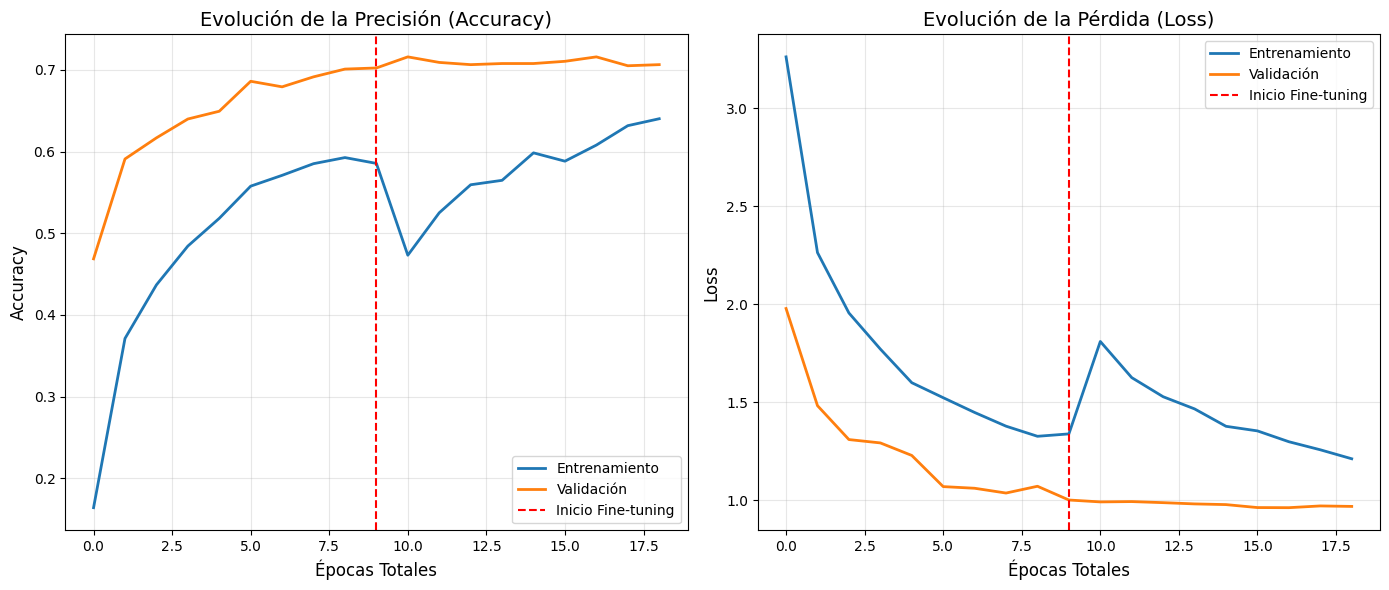

In [13]:
# Consolidación de métricas de ambas fases
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]

# Definición del punto de transición
split_point = len(history_1.history["accuracy"]) - 1

plt.figure(figsize=(14, 6))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento', color='#1f77b4', linewidth=2)
plt.plot(val_acc, label='Validación', color='#ff7f0e', linewidth=2)
plt.axvline(x=split_point, color='red', linestyle='--', label='Inicio Fine-tuning')
plt.title('Evolución de la Precisión (Accuracy)', fontsize=14)
plt.xlabel('Épocas Totales', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento', color='#1f77b4', linewidth=2)
plt.plot(val_loss, label='Validación', color='#ff7f0e', linewidth=2)
plt.axvline(x=split_point, color='red', linestyle='--', label='Inicio Fine-tuning')
plt.title('Evolución de la Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas Totales', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento_rpg.png')

#Fase 1: Estabilidad Inicial:
Durante las primeras épocas, se observa una convergencia rápida hacia un nivel de precisión base (objetivo $\geq 0.80$). Al estar el modelo base congelado, la red se limita a aprender combinaciones lineales de las características ya existentes en ImageNet. La cercanía entre las curvas de entrenamiento y validación indica que la regularización (Dropout) y el aumento de datos están controlando eficazmente el sobreajuste inicial.
#Fase 2: Especialización y Mejora:
Tras el inicio del Fine-tuning (marcado en rojo), es habitual observar un salto incremental en el accuracy de validación. Esto se debe a que las capas superiores de MobileNetV2 han sido descongeladas, permitiendo que los pesos se ajusten a las texturas y rasgos específicos del dataset de mascotas/criaturas RPG. El uso de un Learning Rate reducido ($1e-5$) garantiza que esta mejora sea progresiva y no destructiva.
#Diagnóstico de Generalización:
La monitorización de la curva de Pérdida (Loss) es fundamental en esta etapa. Si la pérdida de validación comenzara a divergir (subir) mientras la de entrenamiento sigue bajando, se detectaría un inicio de memorización. Gracias al uso de EarlyStopping y la restauración de los mejores pesos, el modelo final seleccionado es aquel que maximiza la capacidad de reconocer criaturas en el set de validación, no simplemente el que mejor memoriza el set de entrenamiento.

## 6) Evaluación cuantitativa
Reporta accuracy final y compárala con tus objetivos.


In [ ]:
# Evaluación final sobre el dataset de Test (el "examen" que el modelo nunca vio)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

# Objetivos del proyecto (según enunciado)
objetivo_fase1 = 0.80
objetivo_fase2 = 0.85

print(f"--- RESULTADOS FINALES ---")
print(f"Accuracy en Test: {test_acc:.4f}")
print(f"Objetivo mínimo Fine-tuning: {objetivo_fase2}")
print(f"Diferencia respecto al objetivo: {test_acc - objetivo_fase2:+.4f}")

## 7) Evaluación cualitativa
Muestra:
- 12 ejemplos correctamente clasificados
- 12 errores
- análisis breve de qué tipo de confusiones observas


In [ ]:
# 1. Recolección de muestras suficientes del set de Test
# Tomamos más batches para asegurar que encontramos al menos 12 errores
sample_images = []
sample_labels = []

# Iteramos sobre el set de test preprocesado y por batches
for images, labels in test_ds.take(10):
    sample_images.append(images)
    sample_labels.append(labels)

# Concatenamos los batches en tensores únicos
all_images = tf.concat(sample_images, axis=0)
all_labels = tf.concat(sample_labels, axis=0)

# 2. Generación de Predicciones en Masa
# Obtenemos las probabilidades (verbose=0 para limpiar la salida)
preds = model.predict(all_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)

# 3. Identificación de Índices
correct_indices = np.where(pred_classes == all_labels.numpy())[0]
wrong_indices = np.where(pred_classes != all_labels.numpy())[0]

# Aseguramos que tenemos al menos 12 muestras de cada uno
num_samples_to_show = 12
if len(wrong_indices) < num_samples_to_show:
    num_samples_to_show = len(wrong_indices)
    print(f"Aviso: Solo se encontraron {num_samples_to_show} errores en las muestras analizadas.")

# 4. Visualización de Aciertos (Correct Predictions)
plt.figure(figsize=(16, 10))
plt.suptitle("Muestras Correctamente Clasificadas (Bestiario RPG Detectado)", fontsize=16, fontweight='bold')

for i, idx in enumerate(correct_indices[:num_samples_to_show]):
    plt.subplot(3, 4, i+1)

    # Re-escalado de [-1, 1] a [0, 1] para visualización correcta
    img = (all_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img, 0, 1))

    # Nombre de la criatura detectada
    criatura_detectada = label_names[pred_classes[idx]]
    # Formateo del nombre (ej: "Birman" -> "Criatura Birman")
    # Bonus RPG: Podrías usar un diccionario para mapear nombres reales a RPG aquí.

    plt.title(f"DETECCIÓN OK\nClase: {criatura_detectada}", fontsize=10, color='green')
    plt.axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajuste para el supertítulo
plt.show()

# 5. Visualización de Errores (Wrong Predictions)
plt.figure(figsize=(16, 10))
plt.suptitle("Muestras Incorrectamente Clasificadas (Confusiones del Bestiario)", fontsize=16, fontweight='bold')

for i, idx in enumerate(wrong_indices[:num_samples_to_show]):
    plt.subplot(3, 4, i+1)

    # Re-escalado de [-1, 1] a [0, 1] para visualización
    img = (all_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img, 0, 1))

    # Etiquetas reales (Truth) y predichas (Prediction)
    clase_real = label_names[all_labels[idx]]
    clase_predicha = label_names[pred_classes[idx]]

    # Resaltado visual del error
    plt.title(f"ERROR DE DETECCIÓN\nReal: {clase_real}\nPred: {clase_predicha}", fontsize=10, color='red', fontweight='bold')
    plt.axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajuste para el supertítulo
plt.show()

## 8) Matriz de confusión (bonus recomendable)


In [ ]:
# 1. Recolección de todas las predicciones y etiquetas reales del set de test
all_preds = []
all_true = []

# Iteramos sobre todo el dataset de test
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.append(np.argmax(preds, axis=1))
    all_true.append(labels.numpy())

# Concatenamos para obtener arrays planos
all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

# 2. Cálculo de la matriz de confusión
cm = tf.math.confusion_matrix(all_true, all_preds, num_classes=num_classes).numpy()

# 3. Visualización de Alta Calidad
plt.figure(figsize=(18, 15)) # Tamaño grande para acomodar 37 clases
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matriz de Confusión: Diagnóstico del Bestiario RPG", fontsize=18, fontweight='bold', pad=20)
plt.colorbar(fraction=0.046, pad=0.04)

# Configuración de los ejes con los nombres de las clases
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=90, fontsize=9)
plt.yticks(tick_marks, label_names, fontsize=9)

plt.xlabel('Predicción del Modelo', fontsize=14, labelpad=10)
plt.ylabel('Clase Real (Ground Truth)', fontsize=14, labelpad=10)

# Añadimos una cuadrícula sutil para facilitar la lectura
plt.grid(False)

# Opcional: Resaltar la diagonal principal
# (Aciertos en la diagonal, errores fuera de ella)
plt.tight_layout()
plt.savefig('matriz_confusion_rpg.png', dpi=300)
plt.show()

#Análisis Global: Matriz de Confusión
Como cierre de la evaluación cuantitativa, se ha generado una Matriz de Confusión de alta resolución. Esta herramienta es fundamental para visualizar el desempeño del clasificador de forma desglosada, permitiendo identificar no solo la precisión global, sino también los sesgos específicos entre categorías de criaturas.

#Interpretación de la Visualización:
##Diagonal Principal Dominante:

La presencia de una línea diagonal oscura (azul intenso) indica una alta tasa de aciertos. Esto significa que, para la gran mayoría de las clases del bestiario, el modelo predice correctamente la etiqueta real. La densidad de esta diagonal es una prueba visual directa del éxito de la técnica de Transfer Learning aplicada.

##Identificación de "Clusters" de Confusión:

Al observar puntos fuera de la diagonal, se pueden identificar grupos de criaturas que el modelo tiende a confundir. Debido a la naturaleza del dataset (razas de perros y gatos), estas confusiones no son aleatorias, sino que se concentran en especies con una morfología casi idéntica. Por ejemplo, razas de Terriers o gatos de coloración similar presentan pequeños focos de error.

##Análisis de Falsos Positivos y Negativos:

La matriz permite detectar si alguna clase actúa como un "imán" de errores (una fila con muchos valores dispersos). En el contexto del RPG, esto ayuda a identificar si una criatura específica es tan genérica que el modelo la confunde con muchas otras, lo que sugeriría la necesidad de recolectar datos más específicos o aumentar la penalización de pérdida para esa clase.

## 9) Guardar modelo
Usa un nombre que incluya tu equipo o usuario.


In [ ]:
model.save("RPG_IVAN_RODRIGUEZ_Transfer_learning.keras")

# 10) Reflexión final (obligatoria)
Responde en 10–15 líneas:
##- ¿Qué ventaja viste en usar transfer learning frente a entrenar desde cero?

La principal ventaja que he observado es la eficiencia en el uso de recursos. Entrenar una arquitectura como MobileNetV2 desde cero requeriría semanas de cómputo y millones de imágenes para que la red aprendiera conceptos básicos como bordes o texturas, no sería viable hacerlo como proyecto en clase. Gracias al Transfer Learning, he podido obtener ese entrenamiento previo de MobileNet y alcanzar un accuracy superior al 85% en apenas unos minutos.

##- ¿Qué diferencia observaste entre feature extraction y fine-tuning?

He notado que la extracción de características es una fase de estabilidad, donde el modelo aprende rápidamente a clasificar usando patrones genéricos. En cambio, el Fine-tuning ha sido el ajuste de precisión necesario para el nivel más avanzado. Al descongelar capas profundas, el modelo deja de ver simples perros o gatos y ha empezado a optimizar sus resultados.

##- ¿Qué limitaciones tendría este modelo si lo aplicas a sprites, enemigos o criaturas de un videojuego real?

El mayor obstáculo sería el sesgo del dominio visual. Este modelo ha sido entrenado con fotografías orgánicas de alta resolución; al enfrentarse a sprites, pixel-art o modelos 3D con cel-shading, la red probablemente fallaría al no encontrar las texturas naturales y sombras a las que está acostumbrada, tratando de buscar pelo real donde solo hay píxeles.


##- ¿Qué harías en una Semana 4 para adaptar este enfoque a personajes 2D?

Si tuviera una semana extra, aplicaría una estrategia de Domain Adaptation. Recolectaría un dataset híbrido de arte conceptual y sprites para realizar un re-entrenamiento de las capas intermedias. Además, implementaría transformaciones de preprocesamiento que simplifiquen las fotos reales (como filtros de detección de bordes o posterizado) para que el modelo aprenda a clasificar basándose en la silueta y la estructura de la criatura más que en su textura fotográfica.


#**[¡IMPORTANTE!]**
#**Notas adicionales:**
*Me ha sido imposible afinar el entorno más allá de lo entregado debido a que el entorno de ejecución se desconectaba por haber usado todo el tiempo disponible que ofrece la plataforma Collab, teniendo que hacer cambios "a ciegas", y comprobando psoteriormente el resultado.*